In [1]:
import os # for environment variables
import pandas as pd # for dataframes
import numpy as np # for numerical operations

import requests # for making HTTP requests
import json # for parsing JSON
from bs4 import BeautifulSoup # for parsing HTML
import boto3 # for interacting with AWS S3

from IPython.display import HTML, display # for displaying HTML
%matplotlib inline
import matplotlib.pyplot as plt
import csv
import io
import requests

In [7]:
with zipfile.ZipFile("27856055.zip") as z:
    z.extractall("data")

In [63]:

BK = pd.read_csv('data/data_ws2025/BK.csv')
CAH = pd.read_csv('data/data_ws2025/CAH.csv')
JBHT = pd.read_csv('data/data_ws2025/JBHT.csv')
WEC = pd.read_csv('data/data_ws2025/WEC.csv')
firms = {"BK": BK, "CAH": CAH, "JBHT": JBHT, "WEC": WEC}

In [64]:
for firm, data in firms.items():
    data['Ticker'] = firm

In [65]:
for firm, data in firms.items():
    data['Date'] = pd.to_datetime(data['Date'])

In [18]:
BK.info() # it is datetime

<class 'pandas.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1004 non-null   datetime64[us]
 1   Open          1004 non-null   float64       
 2   High          1004 non-null   float64       
 3   Low           1004 non-null   float64       
 4   Close         1004 non-null   float64       
 5   Volume        1004 non-null   int64         
 6   Dividends     1004 non-null   float64       
 7   Stock Splits  1004 non-null   float64       
 8   Ticks         1004 non-null   str           
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 70.7 KB


In [66]:
for firm, data in firms.items():
    if (data['High'] == data["Low"]).all():
        print(f'This Ticker does not have differences between High and Low: {firm}.')
    else:
        print(f'This Ticker does have differences between High and Low: {firm}.')

print(f'All Tickers have differences between high and low, meaning that there is a within-day volatility in the data.')

This Ticker does have differences between High and Low: BK.
This Ticker does have differences between High and Low: CAH.
This Ticker does have differences between High and Low: JBHT.
This Ticker does have differences between High and Low: WEC.
All Tickers have differences between high and low, meaning that there is a within-day volatility in the data.


In [67]:
print(f'Assuming maximum price should be recorded at the "High" column:')
for firm, data in firms.items():
   print(f'The maximum price recorded for {firm} was {data["High"].max()}.')

Assuming maximum price should be recorded at the "High" column:
The maximum price recorded for BK was 80.928.
The maximum price recorded for CAH was 124.441.
The maximum price recorded for JBHT was 215.387.
The maximum price recorded for WEC was 100.206.


In [68]:
for data in firms.values():
    data['Return_log'] = np.log(data['Close']/data['Close'].shift(1))

In [41]:
for firm, data in firms.items():
    print(f' The minimum logarithmic return for {firm} was {data["Return_log"].min()}.')
    print(f' The maximum logarithmic return for {firm} was {data["Return_log"].max()}.')
    print(f' The standard deviation of logarithmic return for {firm} was {data["Return_log"].std()}.')
    print(f' The skewness of logarithmic return for {firm} was {data["Return_log"].skew()}.')

 The minimum logarithmic return for BK was -0.08598555496187718.
 The maximum logarithmic return for BK was 0.07087130731002143.
 The standard deviation of logarithmic return for BK was 0.01592251433400399.
 The skewness of logarithmic return for BK was -0.3633034211332239.
 The minimum logarithmic return for CAH was -0.15382534025120917.
 The maximum logarithmic return for CAH was 0.06777447922721881.
 The standard deviation of logarithmic return for CAH was 0.015335397288615767.
 The skewness of logarithmic return for CAH was -1.0360634904635977.
 The minimum logarithmic return for JBHT was -0.10094846449712128.
 The maximum logarithmic return for JBHT was 0.09156426027407084.
 The standard deviation of logarithmic return for JBHT was 0.017990146935803347.
 The skewness of logarithmic return for JBHT was -0.33320370961903345.
 The minimum logarithmic return for WEC was -0.0456428053996098.
 The maximum logarithmic return for WEC was 0.049290007538786304.
 The standard deviation of lo

In [57]:
BK.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2021-01-04,36.790,36.911,35.691,36.089,5710200,0.0,0.0,BK
1,2021-01-05,36.089,36.729,35.786,36.496,4592400,0.0,0.0,BK
2,2021-01-06,37.673,39.318,37.595,38.963,8467200,0.0,0.0,BK
3,2021-01-07,39.465,39.854,39.162,39.196,5079000,0.0,0.0,BK
4,2021-01-08,39.257,39.352,38.461,38.781,3621000,0.0,0.0,BK


In [69]:
# 4. hihgest and lowest gains
for firm, data in firms.items():
    print(f' The second highest gain for {firm} was on {data.set_index(["Date"])["Return_log"].nlargest(2).index[1]}.')
    print(f' The second highest loss for {firm} was on {data.set_index(["Date"])["Return_log"].nsmallest(2).index[1]}.')
    

 The second highest gain for BK was on 2021-01-06 00:00:00.
 The second highest loss for BK was on 2021-01-20 00:00:00.
 The second highest gain for CAH was on 2023-11-03 00:00:00.
 The second highest loss for CAH was on 2021-05-06 00:00:00.
 The second highest gain for JBHT was on 2021-10-15 00:00:00.
 The second highest loss for JBHT was on 2022-05-18 00:00:00.
 The second highest gain for WEC was on 2023-12-13 00:00:00.
 The second highest loss for WEC was on 2023-10-02 00:00:00.


In [76]:
# 5. median weekly volume 
for firm, data in firms.items():
    print(f' The median weekly volume for {firm} is {data["Volume"].rolling(7).sum().median()}.')

 The median weekly volume for BK is 31465850.0.
 The median weekly volume for CAH is 16039250.0.
 The median weekly volume for JBHT is 4864600.0.
 The median weekly volume for WEC is 10460800.0.


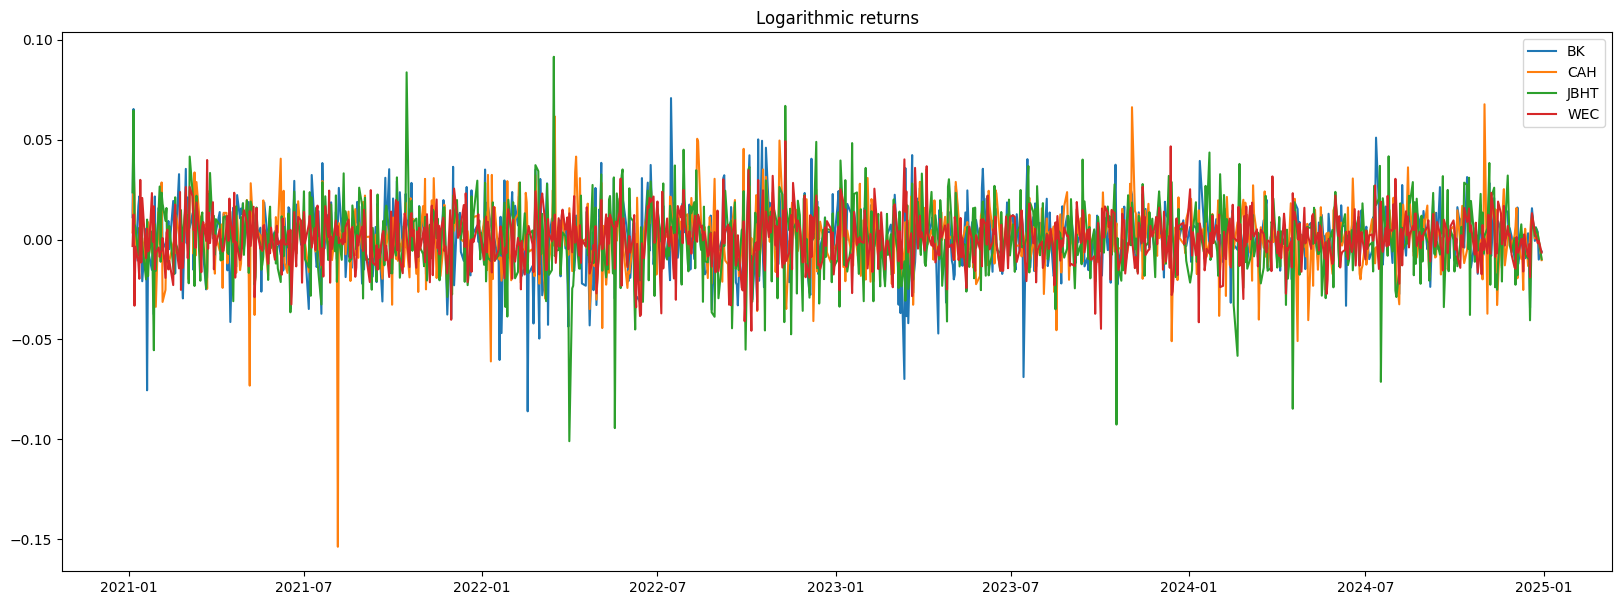

In [71]:
# 8. A plot the log returns
plt.subplots(1,1, figsize = (20,7))
for firm, data in firms.items():
    plt.plot(data['Date'], data['Return_log'], label = firm)
plt.legend()
plt.title("Logarithmic returns")
plt.show()

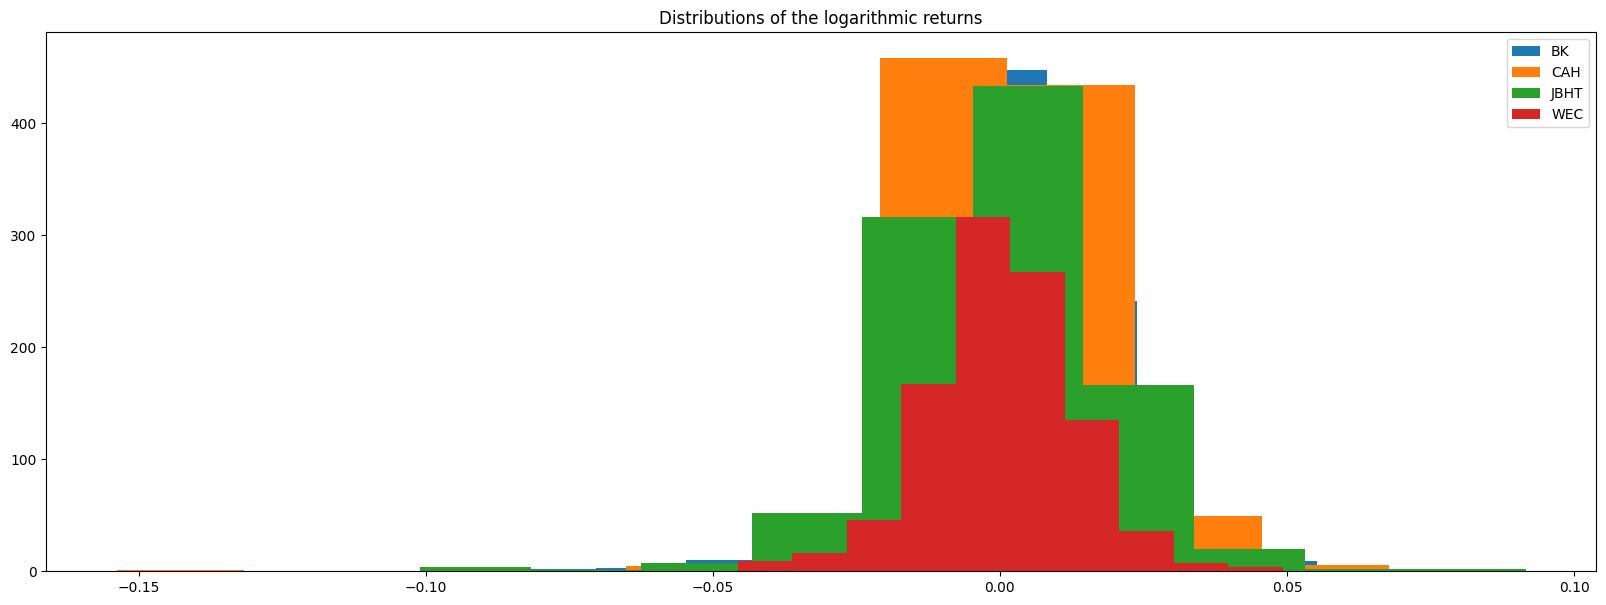

In [73]:
# 8. B plot the distributions of the  log returns
plt.subplots(1,1, figsize = (20,7))
for firm, data in firms.items():
    plt.hist(data['Return_log'], label = firm)
plt.legend()
plt.title("Distributions of the logarithmic returns")
plt.show()

# Task 2

In [79]:
# load data
df_ind = pd.read_csv("companies_no_subindustry.csv")

In [90]:
# 1. comp with missing inclusion date
print(f'There are {df_ind["included"].isnull().sum()} companies with missing inclusion dates.')

There are 45 companies with missing inclusion dates.


In [92]:
df_ind_filt = df_ind['included'].isnull()